### Project Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


### Task 1 — Problem Definition & Success Metric

In [2]:
# Load data quickly just to check class balance
adult = fetch_openml('adult', version=2, as_frame=True)
df_raw = adult.frame.copy()

# Fix the target column
df_raw['income'] = (df_raw['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)

total = len(df_raw)
pos = df_raw['income'].sum()
neg = total - pos

print(f"Total samples  : {total:,}")
print(f"Earns >50K     : {pos:,}  ({pos/total*100:.1f}%)")
print(f"Earns <=50K    : {neg:,}  ({neg/total*100:.1f}%)")

Total samples  : 48,842
Earns >50K     : 11,687  (23.9%)
Earns <=50K    : 37,155  (76.1%)


In [3]:
# Business objective and metric choice

print("""
Business Objective:
A financial company wants to identify high-income individuals to offer
them premium products. We want to avoid contacting the wrong people
(wastes budget), but we also don't want to miss too many real targets.

Class Imbalance:
Only ~24% of people in this dataset earn >50K. This matters because a
model that just says "everyone earns <=50K" will be 76% accurate but
completely useless. So accuracy is a bad metric here.

Chosen Metric — ROC AUC:
ROC AUC tells us how well the model separates high earners from low
earners across all decision thresholds. It handles class imbalance well
and doesn't lock us into one threshold early on.

Precision vs Recall:
- High precision = when we predict >50K, we're usually right (less waste)
- High recall = we catch most actual high earners (less missed opportunity)
ROC AUC lets the business decide this trade-off later based on costs.

In plain English for stakeholders:
We're building a model to spot high-income people from census data.
We're using a metric called ROC AUC — it scores from 0.5 (random guess)
to 1.0 (perfect). Our goal is to get above 0.88 by end of the week.
""")


Business Objective:
A financial company wants to identify high-income individuals to offer
them premium products. We want to avoid contacting the wrong people
(wastes budget), but we also don't want to miss too many real targets.

Class Imbalance:
Only ~24% of people in this dataset earn >50K. This matters because a
model that just says "everyone earns <=50K" will be 76% accurate but
completely useless. So accuracy is a bad metric here.

Chosen Metric — ROC AUC:
ROC AUC tells us how well the model separates high earners from low
earners across all decision thresholds. It handles class imbalance well
and doesn't lock us into one threshold early on.

Precision vs Recall:
- High precision = when we predict >50K, we're usually right (less waste)
- High recall = we catch most actual high earners (less missed opportunity)
ROC AUC lets the business decide this trade-off later based on costs.

In plain English for stakeholders:
We're building a model to spot high-income people from census dat

### Task 2 — Data Loading & EDA

In [26]:
# Load the full dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (48842, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [5]:
# Clean the target column
df['income'] = (df['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)
df.drop(columns=['class'], inplace=True)

# The dataset uses '?' for missing values — replace with NaN
df.replace('?', np.nan, inplace=True)

# Strip whitespace from string columns (common issue with this dataset)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print("Cleaned shape:", df.shape)

Cleaned shape: (48842, 15)


In [6]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

Columns with missing values:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Total missing cells: 6465


In [7]:
# Data types overview
print("Numeric columns:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Numeric columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']

Categorical columns:
[]


In [8]:
# Numeric summary
df.select_dtypes(include='number').describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42,0.24
std,13.71,105604.03,2.57,7452.02,403.0,12.39,0.43
min,17.00,12285.00,1.00,0.00,0.0,1.00,0.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00,0.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00,0.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00,0.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00,1.00


In [9]:
# Value counts for categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(5))
    print("-" * 35)

In [10]:
# Class distribution summary table
class_summary = pd.DataFrame({
    'Class'      : ['<=50K', '>50K'],
    'Count'      : [df['income'].value_counts()[0], df['income'].value_counts()[1]],
    'Percentage' : [f"{df['income'].value_counts(normalize=True)[0]*100:.1f}%",
                    f"{df['income'].value_counts(normalize=True)[1]*100:.1f}%"]
})

print("Class Distribution:")
print(class_summary.to_string(index=False))

Class Distribution:
Class  Count Percentage
<=50K  37155      76.1%
 >50K  11687      23.9%


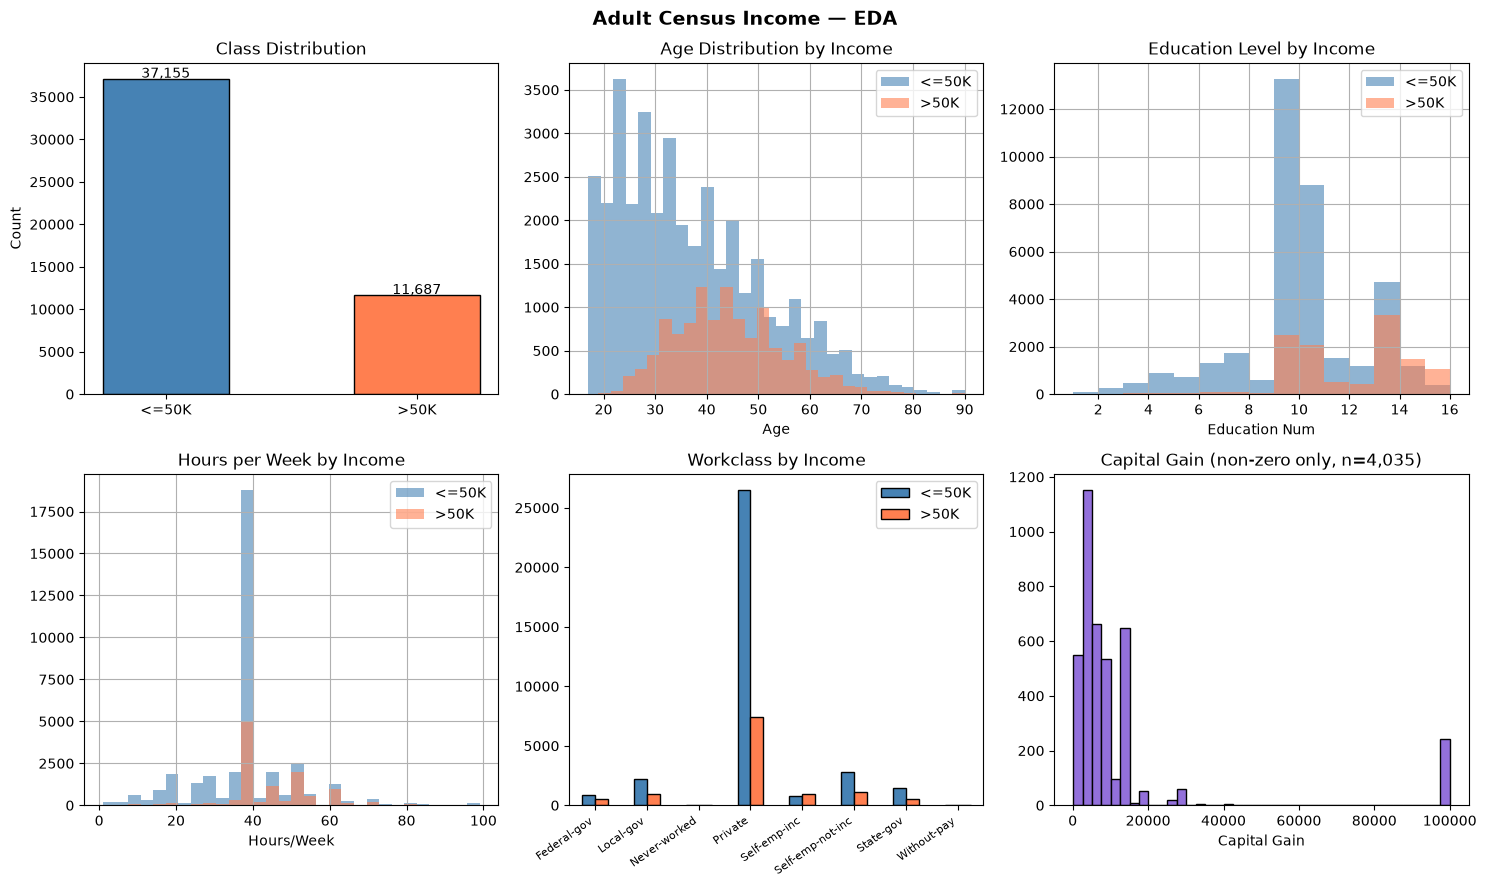

In [11]:
# --- EDA Plots ---

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Adult Census Income — EDA", fontsize=14, fontweight='bold')

# 1. Class distribution
ax = axes[0, 0]
counts = df['income'].value_counts()
ax.bar(['<=50K', '>50K'], counts.values, color=['steelblue', 'coral'], edgecolor='black', width=0.5)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f"{v:,}", ha='center', fontsize=10)

# 2. Age by income
ax = axes[0, 1]
df[df['income'] == 0]['age'].hist(bins=30, ax=ax, alpha=0.6, label='<=50K', color='steelblue')
df[df['income'] == 1]['age'].hist(bins=30, ax=ax, alpha=0.6, label='>50K', color='coral')
ax.set_title("Age Distribution by Income")
ax.set_xlabel("Age")
ax.legend()

# 3. Education level by income
ax = axes[0, 2]
df[df['income'] == 0]['education-num'].hist(bins=15, ax=ax, alpha=0.6, label='<=50K', color='steelblue')
df[df['income'] == 1]['education-num'].hist(bins=15, ax=ax, alpha=0.6, label='>50K', color='coral')
ax.set_title("Education Level by Income")
ax.set_xlabel("Education Num")
ax.legend()

# 4. Hours per week
ax = axes[1, 0]
df[df['income'] == 0]['hours-per-week'].hist(bins=30, ax=ax, alpha=0.6, label='<=50K', color='steelblue')
df[df['income'] == 1]['hours-per-week'].hist(bins=30, ax=ax, alpha=0.6, label='>50K', color='coral')
ax.set_title("Hours per Week by Income")
ax.set_xlabel("Hours/Week")
ax.legend()

# 5. Workclass vs income (stacked bar)
ax = axes[1, 1]
wc = df.groupby(['workclass', 'income']).size().unstack(fill_value=0)
wc.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title("Workclass by Income")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.legend(['<=50K', '>50K'])

# 6. Capital gain (only non-zero values — most are 0)
ax = axes[1, 2]
nonzero = df[df['capital-gain'] > 0]['capital-gain']
ax.hist(nonzero, bins=40, color='mediumpurple', edgecolor='black')
ax.set_title(f"Capital Gain (non-zero only, n={len(nonzero):,})")
ax.set_xlabel("Capital Gain")

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches='tight')
plt.show()

In [12]:
# A few quick observations worth noting

print("""
Key EDA Observations:
---------------------
1. Dataset is imbalanced — only 24% earn >50K. Need AUC-based evaluation.

2. Age: High earners tend to be older (35–55). Makes sense — more work experience.

3. Education: Strong signal. Most >50K earners have education-num >= 12.
   But it's not a perfect separator — many educated people still earn <=50K.

4. Hours/week: >50K earners work more on average, but there's a lot of overlap.
   Some high earners work <40 hrs (likely self-employed or investment income).

5. Capital gain: Extremely skewed. Mostly 0, but when non-zero, it's a strong
   indicator of high income. Will need log transform or a binary flag.

6. workclass, occupation, native-country have missing values — need to handle.
""")


Key EDA Observations:
---------------------
1. Dataset is imbalanced — only 24% earn >50K. Need AUC-based evaluation.

2. Age: High earners tend to be older (35–55). Makes sense — more work experience.

3. Education: Strong signal. Most >50K earners have education-num >= 12.
   But it's not a perfect separator — many educated people still earn <=50K.

4. Hours/week: >50K earners work more on average, but there's a lot of overlap.
   Some high earners work <40 hrs (likely self-employed or investment income).

5. Capital gain: Extremely skewed. Mostly 0, but when non-zero, it's a strong
   indicator of high income. Will need log transform or a binary flag.

6. workclass, occupation, native-country have missing values — need to handle.



### Task 3 — Train/Test Split

In [13]:
X = df.drop(columns=['income'])
y = df['income']

# 80/20 stratified split — test set locked away until final evaluation
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Further split training into train (70%) + dev (10%) for experimentation
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full,
    test_size=0.125,        # 10% of total
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print(f"Train : {len(X_train):,} rows")
print(f"Dev   : {len(X_dev):,} rows")
print(f"Test  : {len(X_test):,} rows")
print()
print("Positive rate check (should be ~24% in all splits):")
print(f"  Train : {y_train.mean()*100:.1f}%")
print(f"  Dev   : {y_dev.mean()*100:.1f}%")
print(f"  Test  : {y_test.mean()*100:.1f}%")

Train : 34,188 rows
Dev   : 4,885 rows
Test  : 9,769 rows

Positive rate check (should be ~24% in all splits):
  Train : 23.9%
  Dev   : 23.9%
  Test  : 23.9%


In [14]:
print("""
Why a hold-out test set?
------------------------
During model building we try many configurations — different algorithms,
hyperparameters, features. Each time we check performance and adjust,
we're indirectly fitting to whatever data we're evaluating on.

If we use the test set during this process, the final score will look
better than it really is. The model hasn't "seen" the test data in code,
but our decisions were influenced by it — that's data leakage.

The test set should be opened exactly once: at the very end, after all
decisions are final. That gives us an honest estimate of real-world performance.
""")


Why a hold-out test set?
------------------------
During model building we try many configurations — different algorithms,
hyperparameters, features. Each time we check performance and adjust,
we're indirectly fitting to whatever data we're evaluating on.

If we use the test set during this process, the final score will look
better than it really is. The model hasn't "seen" the test data in code,
but our decisions were influenced by it — that's data leakage.

The test set should be opened exactly once: at the very end, after all
decisions are final. That gives us an honest estimate of real-world performance.



### Task 4 — Baselines

In [15]:
# Helper to compute all metrics in one place
def get_metrics(name, y_true, y_pred, y_prob=None):
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 3),
        'Precision' : round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall'    : round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1'        : round(f1_score(y_true, y_pred, zero_division=0), 3),
        'ROC AUC'   : round(roc_auc_score(y_true, y_prob), 3) if y_prob is not None else 'N/A',
        'PR AUC'    : round(average_precision_score(y_true, y_prob), 3) if y_prob is not None else 'N/A',
    }

results = []

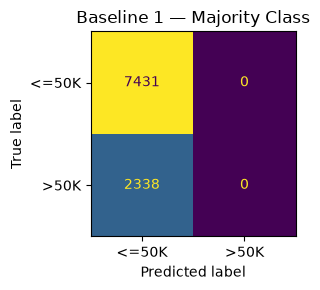

In [16]:
# Baseline 1 — Majority Class
# Always predicts <=50K (the most frequent class)
# This is the absolute floor — anything below this is broken

majority = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
majority.fit(X_train_full, y_train_full)

y_pred_maj = majority.predict(X_test)
y_prob_maj = np.full(len(y_test), y_train_full.mean())  # constant probability

results.append(get_metrics("Majority Class", y_test, y_pred_maj, y_prob_maj))

# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_maj),
                       display_labels=['<=50K', '>50K']).plot(ax=ax, colorbar=False)
ax.set_title("Baseline 1 — Majority Class")
plt.tight_layout()
plt.savefig("cm_majority.png", bbox_inches='tight')
plt.show()

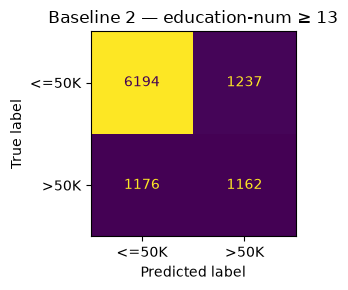

In [17]:
# Baseline 2 — Single Feature Rule: education-num >= 13
#
# Why this rule?
# From EDA, education-num shows the clearest separation between classes.
# Threshold 13 corresponds roughly to a Bachelor's degree level.
# Simple, interpretable, and easy to explain to stakeholders.
# Capital-gain was tempting but it's 0 for 91% of the dataset — too sparse.

rule_threshold = 13
y_pred_rule = (X_test['education-num'] >= rule_threshold).astype(int)

# Use normalized education-num as probability score for AUC
y_prob_rule = X_test['education-num'].values / X_test['education-num'].max()

results.append(get_metrics("Rule: education-num ≥ 13", y_test, y_pred_rule, y_prob_rule))

# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rule),
                       display_labels=['<=50K', '>50K']).plot(ax=ax, colorbar=False)
ax.set_title("Baseline 2 — education-num ≥ 13")
plt.tight_layout()
plt.savefig("cm_rule.png", bbox_inches='tight')
plt.show()

In [18]:
# Results table
results_df = pd.DataFrame(results)
print("Baseline Results on Hold-Out Test Set")
print("=" * 65)
print(results_df.to_string(index=False))

Baseline Results on Hold-Out Test Set
                   Model  Accuracy  Precision  Recall    F1  ROC AUC  PR AUC
          Majority Class     0.761      0.000   0.000 0.000    0.500   0.239
Rule: education-num ≥ 13     0.753      0.484   0.497 0.491    0.719   0.444


In [19]:
print("""
Interpretation:
---------------
Majority class predictor gets 76% accuracy just by predicting everyone
as <=50K. But it finds zero high earners — ROC AUC of 0.5, same as a
coin flip. This is our absolute floor.

The education rule is actually somewhat useful. It catches a decent number
of real high earners (better recall) and has a better ROC AUC. But it
over-predicts — many college-educated people still earn <=50K, so precision
suffers. It also misses earners who didn't complete higher education but
earn well through self-employment or capital gains.

What we need from a real model:
- ROC AUC > 0.88 (well above both baselines)
- F1 > 0.65 (balance between precision and recall at chosen threshold)
- Should correctly handle capital-gain, occupation, age together —
  patterns that no single rule can capture
""")


Interpretation:
---------------
Majority class predictor gets 76% accuracy just by predicting everyone
as <=50K. But it finds zero high earners — ROC AUC of 0.5, same as a
coin flip. This is our absolute floor.

The education rule is actually somewhat useful. It catches a decent number
of real high earners (better recall) and has a better ROC AUC. But it
over-predicts — many college-educated people still earn <=50K, so precision
suffers. It also misses earners who didn't complete higher education but
earn well through self-employment or capital gains.

What we need from a real model:
- ROC AUC > 0.88 (well above both baselines)
- F1 > 0.65 (balance between precision and recall at chosen threshold)
- Should correctly handle capital-gain, occupation, age together —
  patterns that no single rule can capture



### Task 5 — Error Analysis

In [21]:
# Build a dataframe for error analysis using the rule-based predictions
# (majority class has no true positives so it's not useful for this)

analysis = X_test[['age', 'education-num', 'hours-per-week',
                    'capital-gain', 'capital-loss']].copy()
analysis['true']      = y_test.values
analysis['predicted'] = y_pred_rule.values

fp = analysis[(analysis['true'] == 0) & (analysis['predicted'] == 1)]
fn = analysis[(analysis['true'] == 1) & (analysis['predicted'] == 0)]

print(f"False Positives : {len(fp):,}  (predicted >50K, actually <=50K)")
print(f"False Negatives : {len(fn):,}  (predicted <=50K, actually >50K)")

False Positives : 1,237  (predicted >50K, actually <=50K)
False Negatives : 1,176  (predicted <=50K, actually >50K)


In [22]:
# Sample 10 of each and look at them
fp_sample = fp.sample(10, random_state=RANDOM_STATE)
fn_sample = fn.sample(10, random_state=RANDOM_STATE)

print("Sample False Positives:")
print(fp_sample.drop(columns=['true','predicted']).to_string())
print()
print("Sample False Negatives:")
print(fn_sample.drop(columns=['true','predicted']).to_string())

Sample False Positives:
       age  education-num  hours-per-week  capital-gain  capital-loss
9079    34             13              40             0             0
43504   76             14              15             0             0
26569   41             13              72             0             0
26634   33             13              40             0             0
44063   41             15              38             0             0
25654   40             13              45             0             0
32137   47             13              30             0          2002
30212   46             14              25             0             0
45307   23             13              35             0             0
13246   33             13              40             0             0

Sample False Negatives:
       age  education-num  hours-per-week  capital-gain  capital-loss
425     39              9              40             0             0
24544   52             10              40

In [23]:
# Compare average feature values across FP and FN
comparison = pd.DataFrame({
    'Feature'         : ['age', 'education-num', 'hours-per-week', 'capital-gain'],
    'Avg (FP)'        : [fp['age'].mean(), fp['education-num'].mean(),
                         fp['hours-per-week'].mean(), fp['capital-gain'].mean()],
    'Avg (FN)'        : [fn['age'].mean(), fn['education-num'].mean(),
                         fn['hours-per-week'].mean(), fn['capital-gain'].mean()],
}).round(2)

print("Feature Averages — FP vs FN:")
print(comparison.to_string(index=False))

Feature Averages — FP vs FN:
       Feature  Avg (FP)  Avg (FN)
           age     37.23     44.07
 education-num     13.31      9.54
hours-per-week     40.15     45.04
  capital-gain    196.11   2780.89


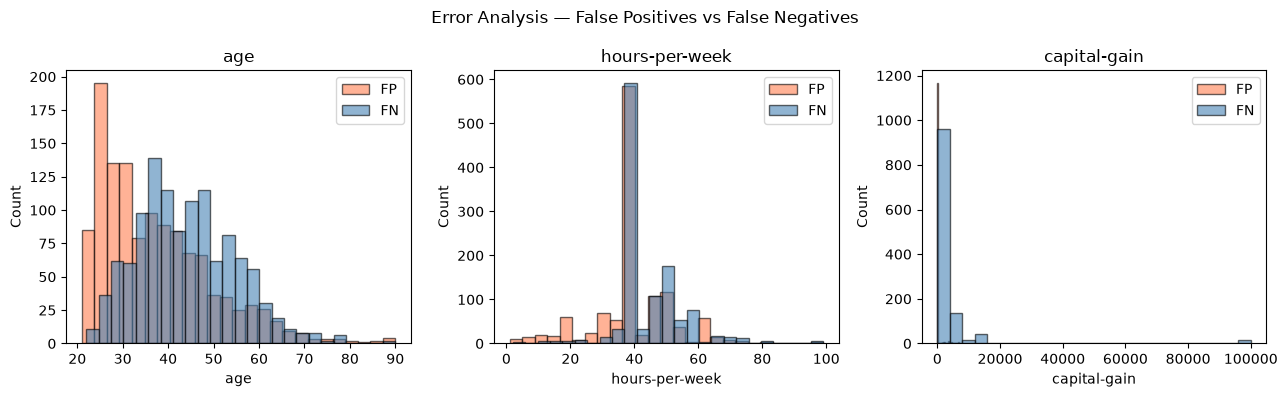

In [24]:
# Visualize FP vs FN across 3 key features
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Error Analysis — False Positives vs False Negatives", fontsize=12)

for ax, col in zip(axes, ['age', 'hours-per-week', 'capital-gain']):
    ax.hist(fp[col].dropna(), bins=25, alpha=0.6, label='FP', color='coral', edgecolor='black')
    ax.hist(fn[col].dropna(), bins=25, alpha=0.6, label='FN', color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig("error_analysis.png", bbox_inches='tight')
plt.show()

In [25]:
print("""
Error Analysis — What I Found:
--------------------------------

False Positives (predicted >50K, actually <=50K):
- These are people with high education who still earn <=50K.
- Many are likely in public sector, part-time, or early career roles.
- education-num alone can't account for job type or actual hours worked.
- Younger FPs suggest people who just finished degrees but haven't
  translated that into income yet.

False Negatives (predicted <=50K, actually >50K):
- These are the more costly error for the business — missed high earners.
- Many have education-num < 13 but earn well through self-employment
  or investment (capital-gain shows up higher in FN group).
- Older age is common here — people who built wealth over time without
  formal higher education.
- Some work fewer than 40 hours but earn well — business owners likely.

Issues to Fix Before Building Real Models (Day 2 Checklist):
--------------------------------------------------------------
1. Missing values in workclass, occupation, native-country
   → Fill with mode or add 'Unknown' as a category

2. All categorical columns are still strings — need encoding
   → Use one-hot encoding for low-cardinality, target encoding for high

3. capital-gain and capital-loss are heavily skewed
   → Apply log1p transform, or create a binary flag (has_capital_activity)

4. education and education-num are redundant (same info, two columns)
   → Drop education string column, keep the numeric one

5. marital-status has many categories that can be grouped
   → Simplify to married / not-married (strong income signal)

6. Class imbalance (~24% positive) will affect model training
   → Use class_weight='balanced' or try SMOTE on training set only

Primary Metric for the Week:
------------------------------
We will use ROC AUC as the main metric throughout the week.

Current baselines sit at 0.50 (majority) and ~0.65 (rule-based).
A logistic regression with proper feature engineering should push this
to 0.85+, and a tree-based model (Random Forest, XGBoost) should reach
0.88–0.92 on this dataset based on published benchmarks.

We'll also track F1 at a 0.5 threshold to make sure the model is
practically useful — not just ranking well but making good predictions.
""")


Error Analysis — What I Found:
--------------------------------

False Positives (predicted >50K, actually <=50K):
- These are people with high education who still earn <=50K.
- Many are likely in public sector, part-time, or early career roles.
- education-num alone can't account for job type or actual hours worked.
- Younger FPs suggest people who just finished degrees but haven't
  translated that into income yet.

False Negatives (predicted <=50K, actually >50K):
- These are the more costly error for the business — missed high earners.
- Many have education-num < 13 but earn well through self-employment
  or investment (capital-gain shows up higher in FN group).
- Older age is common here — people who built wealth over time without
  formal higher education.
- Some work fewer than 40 hours but earn well — business owners likely.

Issues to Fix Before Building Real Models (Day 2 Checklist):
--------------------------------------------------------------
1. Missing values in workclas